<a href="https://colab.research.google.com/github/mauriciomau0/Biomechanics-ML/blob/main/Prevendo_Marcha_Paciente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sports2D: Do Vídeo aos Dados

---

## O que fazemos aqui

Usamos filmagens de datasets distintos, [13 idosos saudáveis](https://springernature.figshare.com/collections/The_Toronto_Older_Adults_Gait_Archive_Video_and_3D_Inertial_Motion_Capture_Data_of_Older_Adults_Walking/5515953), dos quais temos 13 videos, e [3 adultos amputados acima do joelho](https://huggingface.co/datasets/ericyxy98/ProGait), dos quais temos 13 videos, usando câmara única. O Sports2D processa o vídeo e devolve arquivos estruturados com posições articulares e ângulos ao longo do tempo.

O notebook faz três coisas:

1. **Carrega e inspeciona** os arquivos `.mot` e `.trc` gerados pelo Sports2D.
2. **Visualiza e analisa** os ângulos articulares e as trajectórias dos marcadores.
3. **Constroi o modelo** para prever qual dos grupos os participantes são atribuídos e interpreta-o usando IA explicável.   
4. **Documenta os pressupostos** — o que o modelo assume, o que não vê, e quando os dados não são fiáveis para uso clínico.

O quarto passo é o **Pilar 1 do Reality-Centric AI**: não esconder as limitações do modelo atrás dos resultados.

O `.mot` e o `.trc` em metros são os arquivos usados neste notebook.

## Entendimento dos Dados

In [1]:
# Carregamento dos dados que estão no google drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from io import StringIO
from google.colab import drive

!git clone https://github.com/mauriciomau0/Biomechanics-ML.git

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

Cloning into 'Biomechanics-ML'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 132 (delta 13), reused 86 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (132/132), 32.90 MiB | 18.72 MiB/s, done.
Resolving deltas: 100% (13/13), done.


---
### Carregar os arquivos, de dois datasets de videos, gerados pelo Sports2D

In [2]:
# Ajusta estes caminhos para as tuas pastas no Drive
BASE_DIR = '/content/Biomechanics-ML/'

GROUPS = {
    'HOA': os.path.join(BASE_DIR, 'data', 'idosos'),
    'TPU': os.path.join(BASE_DIR, 'data', 'amputados'),
}

# Carregadores

def load_mot(filepath):
    """Carrega .mot do Sports2D — ignora cabeçalho até 'endheader'."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
    start = next(i for i, l in enumerate(lines) if l.strip() == 'endheader') + 1
    df = pd.read_csv(StringIO(''.join(lines[start:])), sep='\t')
    return df

def load_trc(filepath):
    """Carrega .trc do Sports2D — devolve DataFrame com colunas Marcador_X/Y/Z."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
    marker_names_raw = lines[3].strip().split('\t')
    df = pd.read_csv(StringIO(''.join(lines[5:])), sep='\t', header=None)
    col_names = ['Frame', 'Time']
    current_marker = ''
    for name in marker_names_raw[2:]:
        if name.strip():
            current_marker = name.strip()
            col_names.append(f'{current_marker}_X')
        elif current_marker:
            already = sum(1 for c in col_names if c.startswith(current_marker + '_'))
            suffix = 'Y' if already == 1 else 'Z'
            col_names.append(f'{current_marker}_{suffix}')
    while len(col_names) < len(df.columns):
        col_names.append(f'UNKNOWN_{len(col_names)}')
    col_names = col_names[:len(df.columns)]
    df.columns = col_names
    return df

# Descoberta automática de participantes

def find_participants(group_dir):
    """Agrupa ficheiros por participante a partir dos .mot encontrados na pasta."""
    participants = []
    if not os.path.isdir(group_dir):
        print(f'  aviso: pasta não encontrada — {group_dir}')
        return participants
    mot_files = sorted(f for f in os.listdir(group_dir) if f.endswith('.mot'))
    for mot_file in mot_files:
        prefix      = mot_file.split('_Sports2D')[0]
        mot_path    = os.path.join(group_dir, mot_file)
        trc_m_path  = os.path.join(group_dir, f'{prefix}_Sports2D_m_person00.trc')
        trc_px_path = os.path.join(group_dir, f'{prefix}_Sports2D_px_person00.trc')
        missing = []
        if not os.path.exists(trc_m_path):  missing.append('trc_m')
        if not os.path.exists(trc_px_path): missing.append('trc_px')
        if missing:
            print(f'  aviso: {prefix} — ficheiro(s) em falta: {missing}')
        participants.append({
            'id':     prefix,
            'group':  None,
            'mot':    mot_path,
            'trc_m':  trc_m_path  if 'trc_m'  not in missing else None,
            'trc_px': trc_px_path if 'trc_px' not in missing else None,
        })
    return participants

# Carregar todos os participantes

all_angles  = {}  # { participant_id: DataFrame }
all_markers = {}  # { participant_id: DataFrame }
manifest    = []

for group_label, group_dir in GROUPS.items():
    participants = find_participants(group_dir)
    print(f'\n── {group_label}: {len(participants)} participante(s)')
    for p in participants:
        pid = p['id']
        try:
            ang = load_mot(p['mot'])
            mrk = load_trc(p['trc_m']) if p['trc_m'] else None
            all_angles[pid]  = ang
            all_markers[pid] = mrk
            duration = ang['time'].iloc[-1]
            manifest.append({
                'participant': pid,
                'group':       group_label,
                'frames':      len(ang),
                'duration_s':  round(duration, 2),
                'trc_m':       'ok' if mrk is not None else 'em falta',
            })
            print(f'  ok  {pid} | {len(ang)} frames | {duration:.2f}s')
        except Exception as e:
            print(f'  erro  {pid}: {e}')

df_manifest = pd.DataFrame(manifest)
print(f'\n── resumo: {len(df_manifest)} participantes')
print(df_manifest.to_string(index=False))
print(df_manifest.groupby('group').size().rename('n').to_string())


── HOA: 13 participante(s)
  ok  OAW01-top | 2035 frames | 78.27s
  ok  OAW02-top | 2158 frames | 71.93s
  ok  OAW03-top | 2146 frames | 71.53s
  ok  OAW04-top | 2367 frames | 78.90s
  ok  OAW05-top | 2182 frames | 77.93s
  ok  OAW06-top | 2127 frames | 70.90s
  ok  OAW07-top | 3025 frames | 100.83s
  ok  OAW08-top | 2144 frames | 71.47s
  ok  OAW09-top | 2065 frames | 68.83s
  ok  OAW10-top | 1754 frames | 70.16s
  ok  OAW11-top | 2166 frames | 72.20s
  ok  OAW12-top | 1729 frames | 69.16s
  ok  OAW13-top | 1977 frames | 73.22s

── TPU: 13 participante(s)
  ok  1_1_1_f | 358 frames | 11.93s
  ok  1_5_1_f_1 | 432 frames | 14.40s
  ok  1_6_1_f | 447 frames | 14.90s
  ok  1_7_1_f | 389 frames | 12.97s
  ok  1_8_1_f | 358 frames | 11.93s
  ok  1_9_1_f | 349 frames | 11.63s
  ok  2_5_3_f_1 | 341 frames | 11.37s
  ok  2_8_1_f | 350 frames | 11.67s
  ok  4_0_1_f_1 | 654 frames | 21.80s
  ok  4_1_1_f | 355 frames | 11.83s
  ok  4_2_1_f_1 | 382 frames | 12.73s
  ok  4_2_2_f_1 | 325 frames | 1

---
### Comparação entre grupos: HOA vs. TPU

Com 16 participantes, a questão é: **estes dois grupos são separáveis a partir dos ângulos articulares?**

A análise corre em três níveis — estatísticas descritivas, séries temporais sobrepostas e índice de simetria por grupo.


In [3]:
lower_limb_cols = ['right knee', 'left knee', 'right hip', 'left hip',
                   'right ankle', 'left ankle']

# média e ROM por participante
rows = []
for pid, ang in all_angles.items():
    grp = df_manifest.loc[df_manifest['participant'] == pid, 'group'].iloc[0]
    available = [c for c in lower_limb_cols if c in ang.columns]
    row = {'participant': pid, 'group': grp}
    for col in available:
        row[f'{col}_mean'] = ang[col].mean()
        row[f'{col}_rom']  = ang[col].max() - ang[col].min()
    rows.append(row)

df_summary = pd.DataFrame(rows)

# estatísticas por grupo
rom_cols  = [c for c in df_summary.columns if c.endswith('_rom')]
mean_cols = [c for c in df_summary.columns if c.endswith('_mean')]

print('── ROM médio por grupo (°)')
display(df_summary.groupby('group')[rom_cols].agg(['mean', 'std']).round(1))

print('\n── ângulo médio por grupo (°)')
display(df_summary.groupby('group')[mean_cols].agg(['mean', 'std']).round(1))

── ROM médio por grupo (°)


right knee_rom        left knee_rom        right hip_rom        \
                mean    std          mean    std          mean   std   
group                                                                  
HOA            100.6  101.2          79.7   79.8          53.3  16.0   
TPU            105.0  114.9         133.8  167.0          33.7   8.5   

      left hip_rom       right ankle_rom        left ankle_rom         
              mean   std            mean    std           mean    std  
group                                                                  
HOA           49.0  15.7          1249.5  676.9         1538.1  878.0  
TPU           36.1   4.8           513.9  277.6          393.3  223.0


── ângulo médio por grupo (°)


right knee_mean       left knee_mean       right hip_mean       \
                 mean   std           mean   std           mean  std   
group                                                                  
HOA              13.9  39.9            7.1  17.4            2.4  1.1   
TPU               7.8   9.0          -12.0  46.0            4.9  3.1   

      left hip_mean      right ankle_mean        left ankle_mean         
               mean  std             mean    std            mean    std  
group                                                                    
HOA             1.8  2.0            119.3  289.4          -212.5  399.8  
TPU             3.8  1.8            -14.0  157.5             2.0  137.5

### Séries temporais sobrepostas — HOA vs. TPU

Selecionamos um participante representativo de cada grupo para visualização direta.
O objetivo não é generalizar a partir de um par, é perceber visualmente
se há diferenças no padrão cinemático que justifiquem um modelo de classificação.


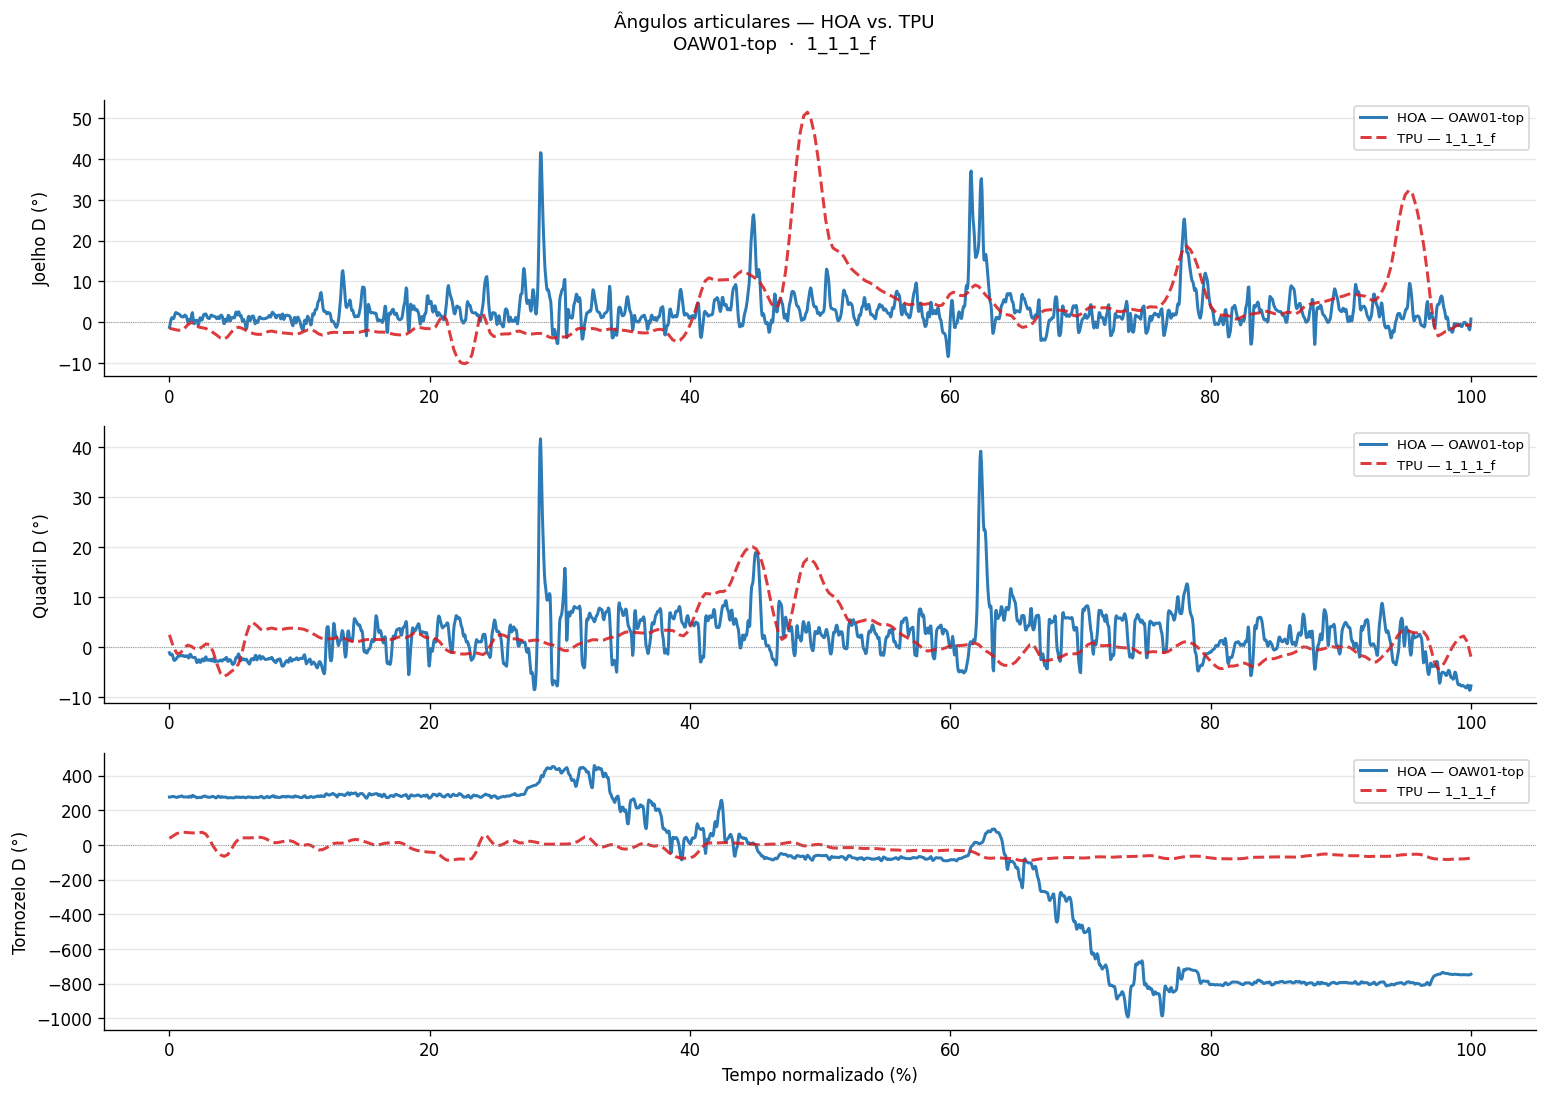

In [4]:
# primeiro participante de cada grupo — altere os índices se preferir outro
pid_hoa = df_manifest.loc[df_manifest['group'] == 'HOA', 'participant'].iloc[0]
pid_tpu = df_manifest.loc[df_manifest['group'] == 'TPU', 'participant'].iloc[0]

ang_hoa = all_angles[pid_hoa]
ang_tpu = all_angles[pid_tpu]

COLOR_HOA = '#2c7bb6'
COLOR_TPU = '#d7191c'

joints_plot = [
    ('right knee',  'Joelho D (°)'),
    ('right hip',   'Quadril D (°)'),
    ('right ankle', 'Tornozelo D (°)'),
]

fig, axes = plt.subplots(len(joints_plot), 1, figsize=(13, 9), sharex=False)

for ax, (col, ylabel) in zip(axes, joints_plot):
    if col in ang_hoa.columns:
        t_hoa = ang_hoa['time'] - ang_hoa['time'].iloc[0]
        t_hoa_pct = t_hoa / t_hoa.iloc[-1] * 100
        ax.plot(t_hoa_pct, ang_hoa[col],
                color=COLOR_HOA, lw=1.8, label=f'HOA — {pid_hoa}')
    if col in ang_tpu.columns:
        t_tpu = ang_tpu['time'] - ang_tpu['time'].iloc[0]
        t_tpu_pct = t_tpu / t_tpu.iloc[-1] * 100
        ax.plot(t_tpu_pct, ang_tpu[col],
                color=COLOR_TPU, lw=1.8, alpha=0.85, label=f'TPU — {pid_tpu}',
                linestyle='--')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.axhline(0, color='gray', lw=0.5, linestyle=':')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xlabel('Tempo normalizado (%)', fontsize=10)
fig.suptitle(
    f'Ângulos articulares — HOA vs. TPU\n'
    f'{pid_hoa}  ·  {pid_tpu}',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

### Trajetórias dos marcadores — HOA vs. TPU

Comparamos as trajetórias no plano de captação de um participante de cada grupo.
No TPU esperamos assimetria espacial marcada entre o lado protésico e o contralateral.


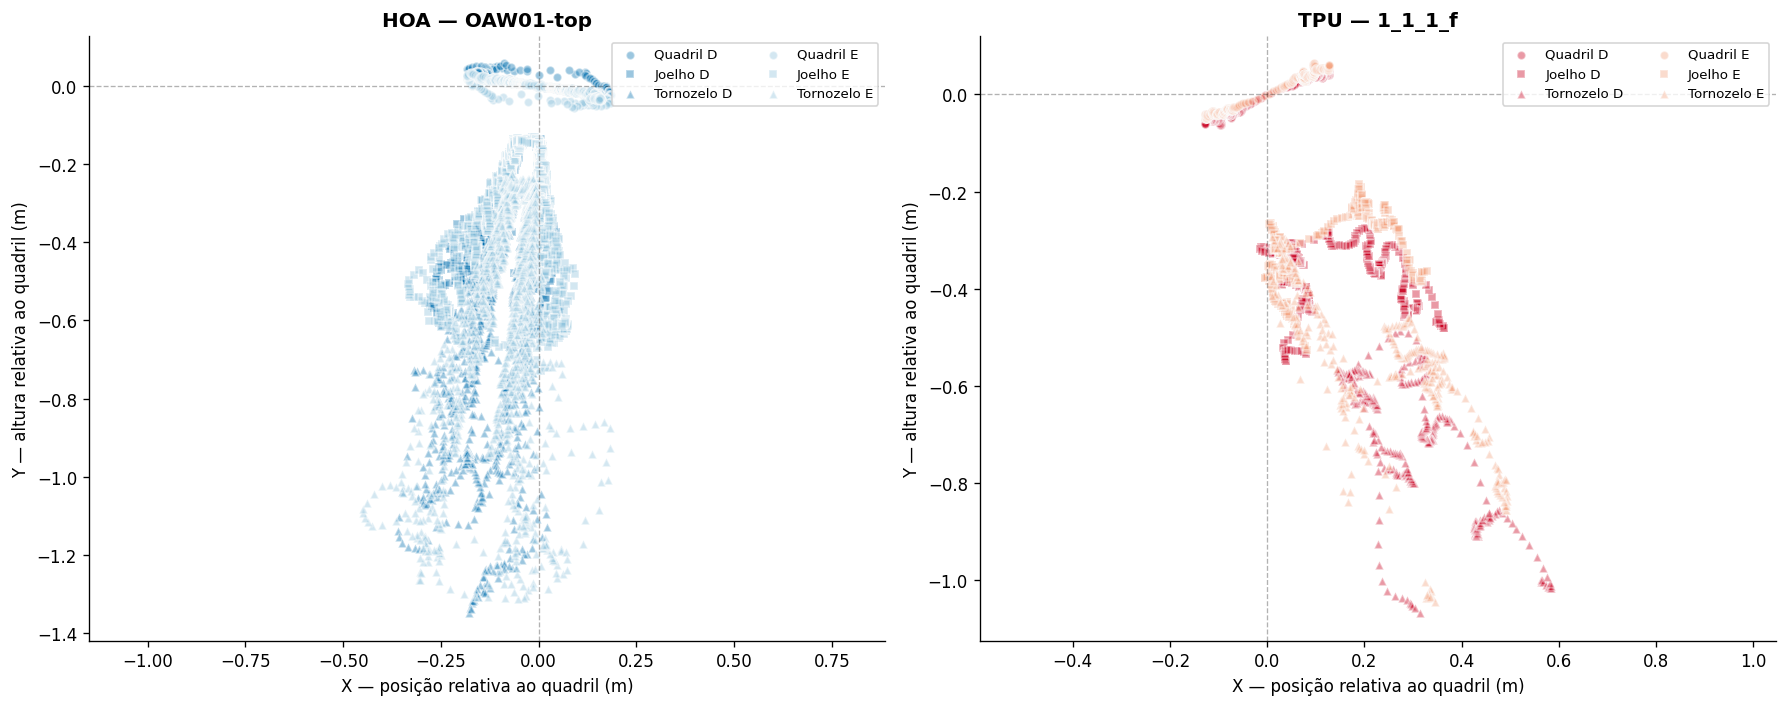

In [5]:
import matplotlib.pyplot as plt


def symmetry_index(val_r, val_l):
    """0% = simétrico; >25% = assimetria marcada."""
    denom = 0.5 * (abs(val_r) + abs(val_l))
    return abs(val_r - val_l) / denom * 100 if denom > 0 else np.nan

def normalize_to_hip_midpoint(mrk_df):
    """Coordenadas X e Y relativas ao ponto médio dinâmico do quadril."""
    df_norm = mrk_df.copy()
    if 'RHip_X' in df_norm.columns and 'LHip_X' in df_norm.columns:
        mid_hip_x = (df_norm['RHip_X'] + df_norm['LHip_X']) / 2
        mid_hip_y = (df_norm['RHip_Y'] + df_norm['LHip_Y']) / 2
        for col in [c for c in df_norm.columns if c.endswith('_X')]:
            df_norm[col] -= mid_hip_x
        for col in [c for c in df_norm.columns if c.endswith('_Y')]:
            df_norm[col] -= mid_hip_y
    return df_norm


all_markers_norm = {pid: normalize_to_hip_midpoint(df) for pid, df in all_markers.items()}

key_markers = {
    'Quadril D':   ('RHip_X',   'RHip_Y'),
    'Joelho D':    ('RKnee_X',  'RKnee_Y'),
    'Tornozelo D': ('RAnkle_X', 'RAnkle_Y'),
    'Quadril E':   ('LHip_X',   'LHip_Y'),
    'Joelho E':    ('LKnee_X',  'LKnee_Y'),
    'Tornozelo E': ('LAnkle_X', 'LAnkle_Y'),
}

marker_styles  = {'Quadril': 'o', 'Joelho': 's', 'Tornozelo': '^'}
colors_config  = {
    'HOA': {'D': '#0571b0', 'E': '#92c5de'},
    'TPU': {'D': '#ca0020', 'E': '#f4a582'},
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (pid, grp_type, grp_label) in zip(axes, [
    (pid_hoa, 'HOA', f'HOA — {pid_hoa}'),
    (pid_tpu, 'TPU', f'TPU — {pid_tpu}'),
]):
    mrk = all_markers_norm.get(pid)
    if mrk is None:
        continue
    for label, (cx, cy) in key_markers.items():
        if cx not in mrk.columns:
            continue
        joint_type = label.split(' ')[0]
        side = 'D' if 'D' in label else 'E'
        ax.scatter(
            mrk[cx], mrk[cy],
            s=25,
            marker=marker_styles.get(joint_type, 'p'),
            color=colors_config[grp_type][side],
            alpha=0.4,
            edgecolors='white',
            label=label,
        )
    ax.set_xlabel('X — posição relativa ao quadril (m)')
    ax.set_ylabel('Y — altura relativa ao quadril (m)')
    ax.set_title(grp_label, fontweight='bold')
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.3)
    ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.3)
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()

## Preparação de Dados

### Extração e Criação de Features (Atributos)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os

# Etapa de processamento: Extração de indicadores de assimetria pareada

def compute_asymmetry_v2(val_r, val_l):
    """
    Calcula o índice de assimetria entre os lados direito e esquerdo.
    A constante 1e-6 é utilizada para garantir a estabilidade numérica do desenvolvimento.
    """
    return np.abs(val_r - val_l) / ((val_r + val_l) / 2 + 1e-6)

si_rows = []

for pid in all_angles.keys():
    # Verifica se o participante existe na base de dados principal
    if pid not in df_manifest['participant'].values:
        continue

    grp = df_manifest.loc[df_manifest['participant'] == pid, 'group'].iloc[0]

    # Recupera os dados cinemáticos e espaciais do participante
    ang = all_angles.get(pid)
    mrk_raw = all_markers.get(pid)
    mrk_norm = all_markers_norm.get(pid)

    if mrk_raw is None or ang is None:
        continue

    row = {'participant': pid, 'group': grp}

    try:
        # Analisa a assimetria articular (Quadril e Joelho)
        # O cálculo baseia-se na Amplitude de Movimento (ROM) comparando ambos os lados
        for joint in ['hip', 'knee']:
            col_r, col_l = f'right {joint}', f'left {joint}'
            rom_r = ang[col_r].max() - ang[col_r].min()
            rom_l = ang[col_l].max() - ang[col_l].min()
            row[f'{joint.capitalize()}_asymmetry'] = compute_asymmetry_v2(rom_r, rom_l)

        # Analisa a assimetria na velocidade da passada (Stride Speed)
        # Estima o deslocamento dos tornozelos no eixo X em relação ao tempo
        dt = mrk_raw['Time'].diff().mean()

        v_r = np.abs(mrk_raw['RAnkle_X'].diff() / dt).mean()
        v_l = np.abs(mrk_raw['LAnkle_X'].diff() / dt).mean()

        row['StrideSpeed_asymmetry'] = compute_asymmetry_v2(v_r, v_l)

        # Consolida indicadores complementares de postura e equilíbrio
        # Mede a variação de nivelamento da pelve entre os lados direito e esquerdo
        diff_pelve = mrk_norm['RHip_Y'] - mrk_norm['LHip_Y']
        row['PelvicTilt_asymmetry'] = compute_asymmetry_v2(abs(diff_pelve.max()), abs(diff_pelve.min()))

        # Mede a oscilação do tronco para identificar desvios posturais
        row['Trunk_asymmetry'] = compute_asymmetry_v2(abs(ang['trunk'].max()), abs(ang['trunk'].min()))

    except Exception as e:
        print(f"Ocorreu uma falha no processamento do participante {pid}: {e}")
        continue

    si_rows.append(row)

# Estruturação final dos resultados para análise estatística
df_si = pd.DataFrame(si_rows)
df_si.head()

,participant,group,Hip_asymmetry,Knee_asymmetry,StrideSpeed_asymmetry,PelvicTilt_asymmetry,Trunk_asymmetry
0,OAW01-top,HOA,0.580583,0.113083,0.072680,0.543339,0.308562
1,OAW02-top,HOA,0.133859,0.155118,0.002110,0.102901,0.179224
2,OAW03-top,HOA,0.161254,0.117188,0.032619,0.392938,0.159912
3,OAW04-top,HOA,0.219912,0.468930,0.006835,0.012699,1.117692
4,OAW05-top,HOA,0.649191,0.291313,0.094048,0.029307,0.622892


/tmp/ipykernel_25035/22020041.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_hoa, data_tpu], patch_artist=True, labels=['HOA', 'TPU'],
/tmp/ipykernel_25035/22020041.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_hoa, data_tpu], patch_artist=True, labels=['HOA', 'TPU'],
/tmp/ipykernel_25035/22020041.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_hoa, data_tpu], patch_artist=True, labels=['HOA', 'TPU'],
/tmp/ipykernel_25035/22020041.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' si

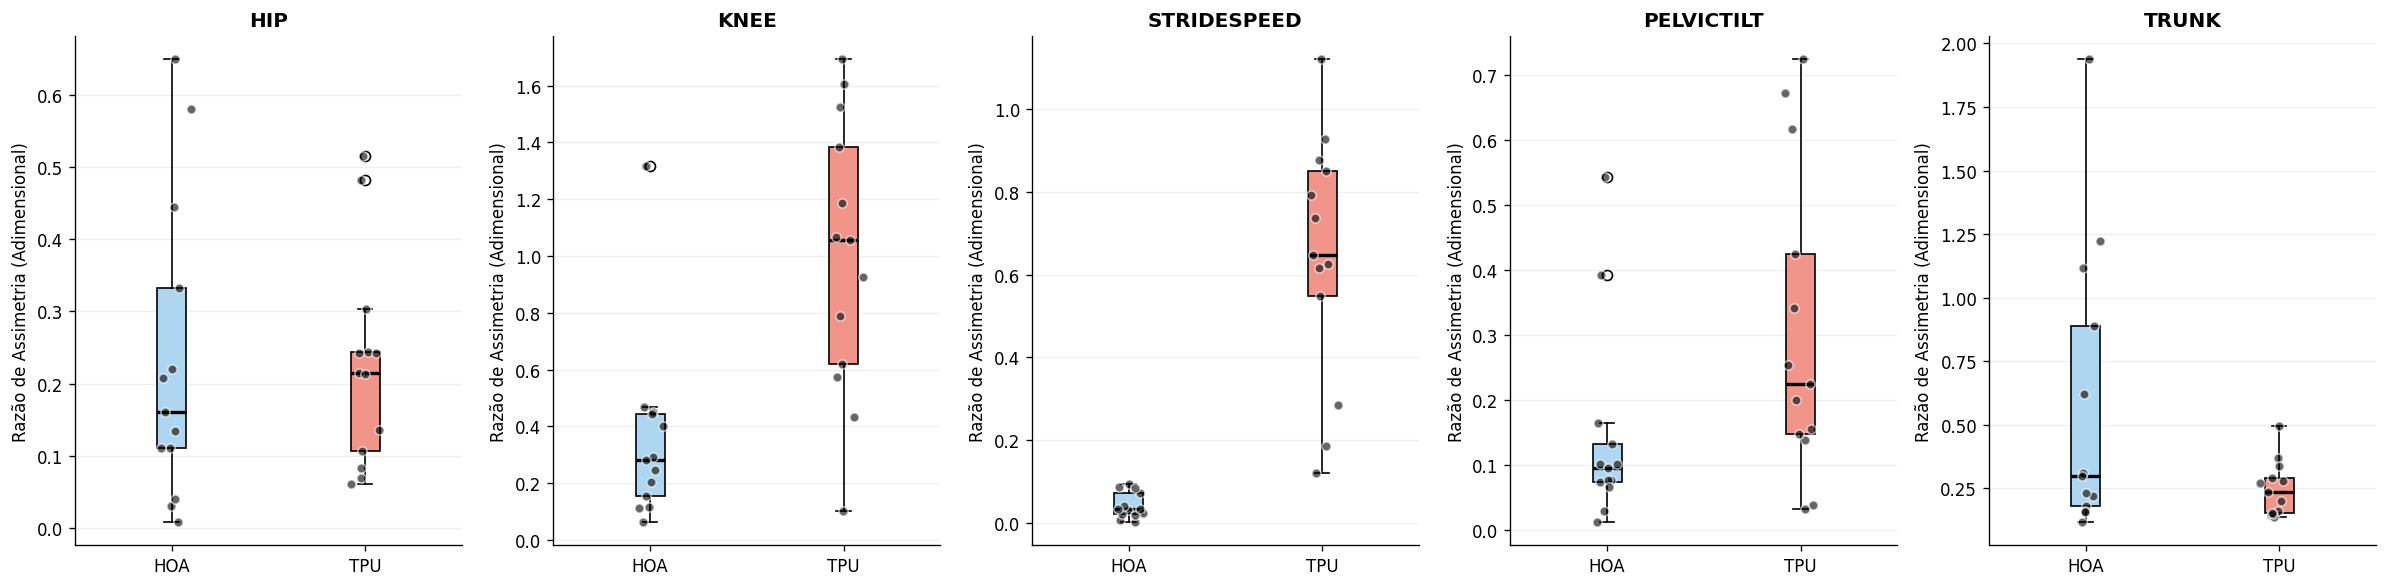

In [7]:
# Etapa de visualização: Análise gráfica das assimetrias pareadas

# Identifica as variáveis de assimetria presentes no conjunto de dados
asym_cols = [c for c in df_si.columns if 'asymmetry' in c]
n_vars = len(asym_cols)

# Configuração da área de plotagem para o desenvolvimento dos gráficos
fig, axes = plt.subplots(1, n_vars, figsize=(4 * n_vars, 5))
if n_vars == 1:
    axes = [axes]

for ax, col in zip(axes, asym_cols):
    # Separação dos dados por grupo experimental (HOA e TPU)
    data_hoa = df_si.loc[df_si['group'] == 'HOA', col].dropna()
    data_tpu = df_si.loc[df_si['group'] == 'TPU', col].dropna()

    # Construção do Boxplot para comparação de distribuições
    bp = ax.boxplot([data_hoa, data_tpu], patch_artist=True, labels=['HOA', 'TPU'],
                    medianprops=dict(color='black', lw=2))

    # Personalização visual para facilitar a distinção entre grupos
    bp['boxes'][0].set_facecolor('#AED6F1') # Grupo HOA em Azul
    bp['boxes'][1].set_facecolor('#F1948A') # Grupo TPU em Coral

    # Inclusão de Jitter para visualização da dispersão individual dos pontos
    for i, data in enumerate([data_hoa, data_tpu], 1):
        x = np.random.normal(i, 0.04, size=len(data))
        ax.scatter(x, data, alpha=0.6, s=30, color='black', edgecolors='white', zorder=3)

    # Formatação de rótulos e títulos dos eixos
    title = col.replace('_asymmetry', '').replace('_', ' ')
    ax.set_title(title.upper(), fontsize=12, fontweight='bold')
    ax.set_ylabel('Razão de Assimetria (Adimensional)')
    ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

## Analise de Dados

### Validação estatística de features (atributos)

In [8]:
# Etapa de análise: Validação estatística por meio do teste de Mann-Whitney U

print("Relatório de Validação Estatística: Indicadores de Assimetria")
stat_results = []

for feature in asym_cols:
    # Separação das amostras por grupo para o desenvolvimento da análise
    data_hoa = df_si.loc[df_si['group'] == 'HOA', feature].dropna()
    data_tpu = df_si.loc[df_si['group'] == 'TPU', feature].dropna()

    # Aplicação do teste não-paramétrico, adequado para distribuições clínicas ou reduzidas
    stat, p_value = mannwhitneyu(data_hoa, data_tpu, alternative='two-sided')

    # Atribuição de níveis de significância estatística
    if p_value < 0.001:
        sig = '***'
    elif p_value < 0.01:
        sig = '**'
    elif p_value < 0.05:
        sig = '*'
    else:
        sig = 'n.s. (não significativo)'

    stat_results.append({
        'Parâmetro': feature.replace('_asymmetry', '').upper(),
        'Mediana HOA': round(data_hoa.median(), 3),
        'Mediana TPU': round(data_tpu.median(), 3),
        'p-value': round(p_value, 4),
        'Significância': sig
    })

# Consolidação dos resultados em um quadro comparativo
df_stats = pd.DataFrame(stat_results)
print(df_stats.to_string(index=False))

Relatório de Validação Estatística: Indicadores de Assimetria
  Parâmetro  Mediana HOA  Mediana TPU  p-value            Significância
        HIP        0.161        0.215   0.7196 n.s. (não significativo)
       KNEE        0.282        1.056   0.0018                       **
STRIDESPEED        0.035        0.649   0.0000                      ***
 PELVICTILT        0.095        0.225   0.0240                        *
      TRUNK        0.297        0.235   0.1998 n.s. (não significativo)


---
### Guardar os dados processados para os próximos notebooks

Exportamos os ângulos dos membros inferiores e superiores num formato limpo.

In [9]:
# Etapa final: Consolidação dos dados para modelos de Machine Learning

# Criação de uma cópia de segurança para preservar o desenvolvimento do dataframe original
df_ml = df_si.copy()

# Codificação da variável de interesse 'group' em um formato binário (target)
# Define TPU (Amputado) como 1 e HOA (Controle) como 0
df_ml['target'] = df_ml['group'].map({'TPU': 1, 'HOA': 0})

# Reorganização estrutural: Identificadores e Target precedem os indicadores de assimetria
cols = ['participant', 'group', 'target'] + [c for c in df_ml.columns if 'asymmetry' in c]
df_ml = df_ml[cols]

# Configuração do diretório de destino para o armazenamento do arquivo processado
processed_dir = os.path.join(BASE_DIR, 'data', 'processed')
os.makedirs(processed_dir, exist_ok=True)

final_path = os.path.join(processed_dir, 'final_gait_ml_features.csv')
df_ml.to_csv(final_path, index=False)

print(f"Caminho do arquivo: {final_path}")
print(f"Dimensões do conjunto de dados: {df_ml.shape} (Amostras x Variáveis)")
display(df_ml.head())

Caminho do arquivo: /content/Biomechanics-ML/data/processed/final_gait_ml_features.csv
Dimensões do conjunto de dados: (26, 8) (Amostras x Variáveis)


,participant,group,target,Hip_asymmetry,Knee_asymmetry,StrideSpeed_asymmetry,PelvicTilt_asymmetry,Trunk_asymmetry
0,OAW01-top,HOA,0,0.580583,0.113083,0.072680,0.543339,0.308562
1,OAW02-top,HOA,0,0.133859,0.155118,0.002110,0.102901,0.179224
2,OAW03-top,HOA,0,0.161254,0.117188,0.032619,0.392938,0.159912
3,OAW04-top,HOA,0,0.219912,0.468930,0.006835,0.012699,1.117692
4,OAW05-top,HOA,0,0.649191,0.291313,0.094048,0.029307,0.622892


## Construindo o modelo


Desempenho do Modelo Random Forest (Validação LOOCV)
Acurácia: 96.2%

              precision    recall  f1-score   support

     HOA (0)       0.93      1.00      0.96        13
     TPU (1)       1.00      0.92      0.96        13

    accuracy                           0.96        26
   macro avg       0.96      0.96      0.96        26
weighted avg       0.96      0.96      0.96        26



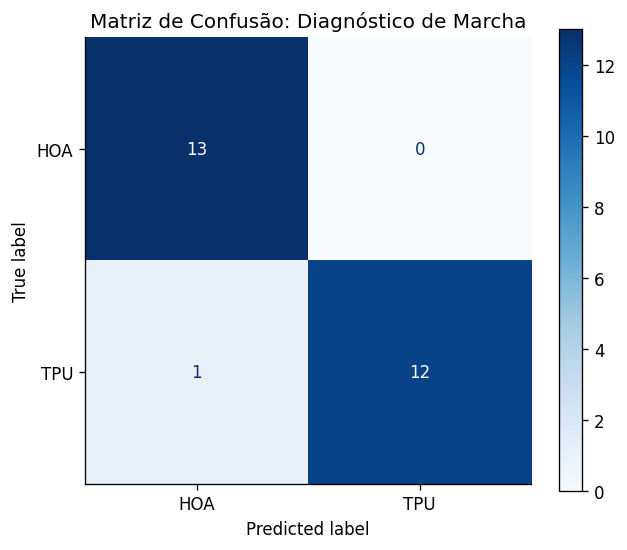


Importância das Variáveis (Modelo Random Forest)
Variável Biomecânica  Importância (Gini)
         StrideSpeed            0.588053
                Knee            0.231772
          PelvicTilt            0.106929
               Trunk            0.047202
                 Hip            0.026045


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# Etapa 5: Aprendizado de Máquina utilizando Random Forest e LOOCV

print("\nDesempenho do Modelo Random Forest (Validação LOOCV)")

ml_df = df_ml.dropna().copy()
feature_cols = [c for c in ml_df.columns if 'asymmetry' in c]

X = ml_df[feature_cols]
y = ml_df['target']

loo = LeaveOneOut()
y_true, y_pred = [], []

# Configuração do modelo: utilizamos um número menor de estimadores para adequação ao tamanho reduzido da amostra
rf_model = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
scaler = StandardScaler()

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    rf_model.fit(X_train_scaled, y_train)
    y_pred.append(rf_model.predict(X_test_scaled)[0])
    y_true.append(y_test.values[0])

# Exibição das métricas gerais de desempenho
print(f"Acurácia: {accuracy_score(y_true, y_pred) * 100:.1f}%\n")
print(classification_report(y_true, y_pred, target_names=['HOA (0)', 'TPU (1)']))

# Configuração e visualização da matriz de confusão
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['HOA', 'TPU'])
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusão: Diagnóstico de Marcha')
plt.show()

# Análise de importância das variáveis utilizando o critério de Gini

# 1. Padronização dos dados para o treinamento final
X_scaled_full = scaler.fit_transform(X)

# Passo necessário: retornar os dados para uma estrutura de DataFrame garantindo a preservação dos nomes das colunas
X_scaled_df = pd.DataFrame(
    X_scaled_full,
    columns=[c.replace('_asymmetry', '').replace('_', ' ') for c in feature_cols]
)

# 2. Treinamento do modelo com o conjunto completo de dados para extrair a importância das variáveis
rf_model.fit(X_scaled_df, y)

importance_df = pd.DataFrame({
    'Variável Biomecânica': [c.replace('_asymmetry', '').replace('_', ' ') for c in feature_cols],
    'Importância (Gini)': rf_model.feature_importances_
}).sort_values(by='Importância (Gini)', ascending=False)

print("\nImportância das Variáveis (Modelo Random Forest)")
print(importance_df.to_string(index=False))

### Interpretabilidade - IA explicável


Analisando a Tomada de Decisão do Modelo com SHAP


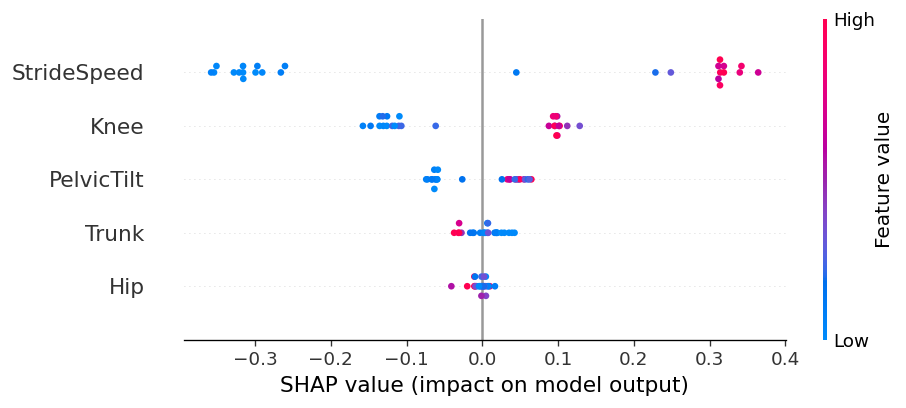

In [11]:
import shap

# Etapa 6: Análise de Impacto das Variáveis com SHAP

print("\nAnalisando a Tomada de Decisão do Modelo com SHAP")

# 1. Instanciar o explicador utilizando o modelo final treinado
explainer = shap.TreeExplainer(rf_model)

# 2. Calcular os valores SHAP com base no DataFrame padronizado
# Utiliza-se check_additivity=False para prevenir erros de validação comuns em modelos Random Forest
shap_values = explainer.shap_values(X_scaled_df, check_additivity=False)

# 3. Extração dos valores correspondentes à Classe 1 (TPU)
# Dependendo da versão do scikit-learn e do SHAP, o formato de saída pode variar.
# Caso o resultado seja uma lista, selecionamos a segunda posição, referente à classe alvo.
if isinstance(shap_values, list):
    val_to_plot = shap_values[1]
else:
    # Tratamento para matrizes tridimensionais (comum em algumas versões mais recentes da biblioteca)
    if len(shap_values.shape) == 3:
        val_to_plot = shap_values[:, :, 1]
    else:
        val_to_plot = shap_values

# 4. Geração do gráfico de resumo global (Summary Plot)
# A chamada direta ao método nativo do SHAP é suficiente e evita cortes ou problemas na renderização da figura
shap.summary_plot(val_to_plot, X_scaled_df, plot_type="dot")


ANÁLISE DO PARTICIPANTE: OAW01-top
Grupo Real: HOA (Saudável) | Predição do Modelo: HOA


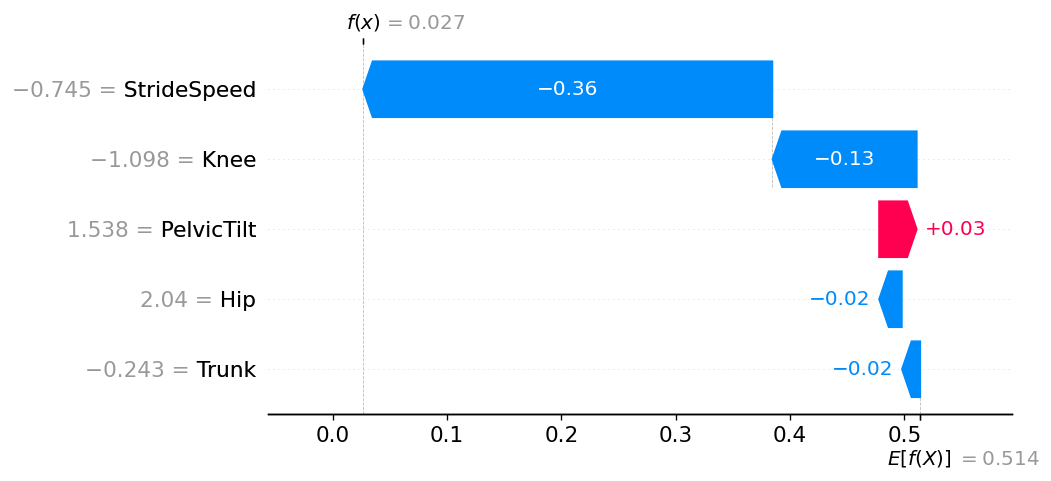


ANÁLISE DO PARTICIPANTE: OAW08-top
Grupo Real: HOA (Saudável) | Predição do Modelo: HOA


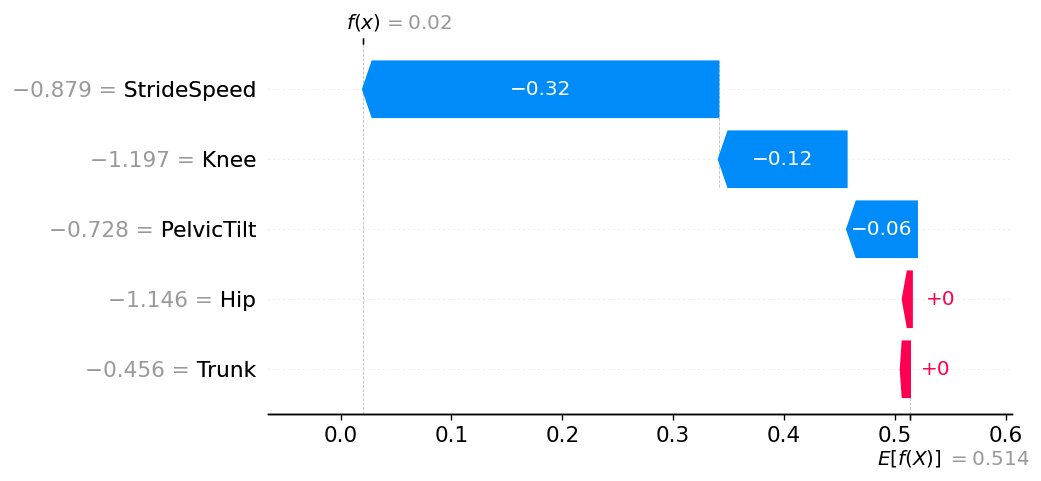


ANÁLISE DO PARTICIPANTE: 1_1_1_f
Grupo Real: TPU (Amputado) | Predição do Modelo: TPU


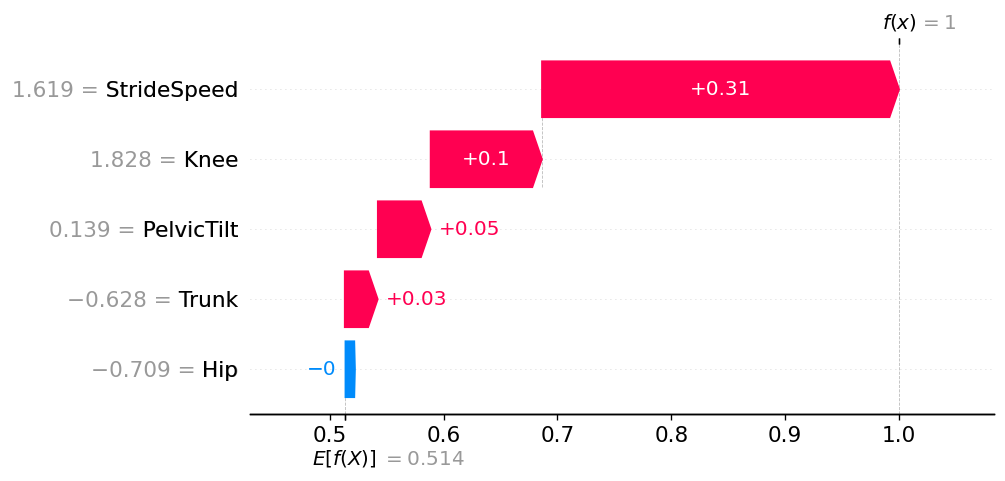


ANÁLISE DO PARTICIPANTE: 1_8_1_f
Grupo Real: TPU (Amputado) | Predição do Modelo: HOA


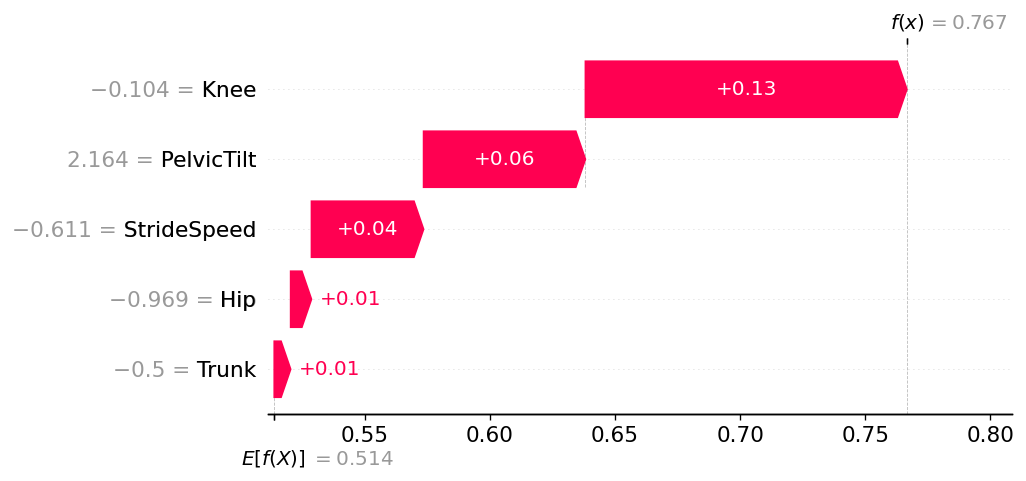

In [12]:
# Etapa 8: Análise Comparativa Sequencial (Gráficos Waterfall Individuais)

# Definição dos índices de interesse: dois participantes do grupo controle (HOA), um caso de sucesso (TPU) e um falso negativo.
# Nota: O índice 17 corresponde ao participante específico '1_8_1_f'.
indices_estudo = [0, 7, 13, 17]

# Padronização dos nomes das variáveis para garantir a legibilidade na geração dos gráficos
clean_feature_names = [c.replace('_asymmetry', '').replace('_', ' ') for c in feature_cols]

for idx in indices_estudo:
    # 1. Identificação do participante e comparação entre diagnóstico real e predição do modelo
    pid = ml_df.iloc[idx]['participant']
    target_real = "TPU (Amputado)" if ml_df.iloc[idx]['target'] == 1 else "HOA (Saudável)"
    predicao = "TPU" if y_pred[idx] == 1 else "HOA"

    print(f"\n" + "="*60)
    print(f"ANÁLISE DO PARTICIPANTE: {pid}")
    print(f"Grupo Real: {target_real} | Predição do Modelo: {predicao}")
    print("="*60)

    # 2. Instanciação do objeto de explicação SHAP focado no indivíduo atual
    exp_individual = shap.Explanation(
        values=val_to_plot[idx], # Utiliza os valores SHAP já calculados para a classe alvo (TPU)
        base_values=explainer.expected_value[1], # Extração do valor base de predição correspondente à classe 1 (TPU)
        data=X_scaled_df.iloc[idx].values,
        feature_names=clean_feature_names # Inserção dos nomes padronizados das variáveis
    )

    # 3. Geração do gráfico Waterfall individual
    # A renderização visual é tratada de forma nativa pela biblioteca SHAP
    shap.plots.waterfall(exp_individual)

### PILAR 6 RCAI: o modelo não decide sozinho


Relatório de Confiança por Participante
Participante       Grupo  Predição    Confiança  Zona       Predição correta?
──────────────────────────────────────────────────────────────────────
OAW01-top          HOA    HOA            75.3%  Amarela    Sim
OAW02-top          HOA    HOA            95.4%  Verde      Sim
OAW03-top          HOA    HOA            73.0%  Amarela    Sim
OAW04-top          HOA    HOA            97.6%  Verde      Sim
OAW05-top          HOA    HOA            91.0%  Verde      Sim
OAW06-top          HOA    HOA            94.0%  Verde      Sim
OAW07-top          HOA    HOA            85.3%  Verde      Sim
OAW08-top          HOA    HOA            93.3%  Verde      Sim
OAW09-top          HOA    HOA            92.0%  Verde      Sim
OAW10-top          HOA    HOA            82.0%  Verde      Sim
OAW11-top          HOA    HOA            58.0%  Vermelha   Sim
OAW12-top          HOA    HOA            86.0%  Verde      Sim
OAW13-top          HOA    HOA            95.8%  Verde 

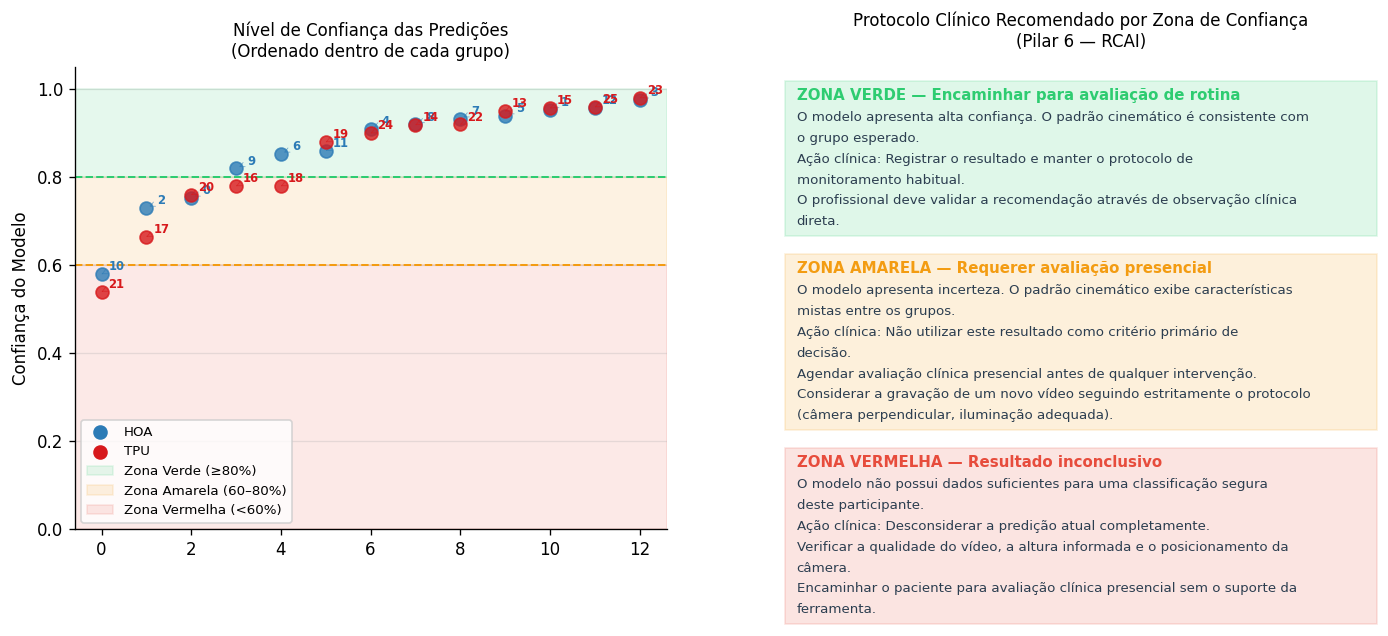

In [13]:
# O modelo classifica os resultados em três zonas de confiança. O profissional clínico
# é responsável pela decisão final em cada zona. A IA atua como
# uma ferramenta de suporte, não emitindo diagnósticos autônomos, mas sim
# recomendações de ação para o profissional qualificado.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

# 1. Definição das zonas clínicas de confiança
# Critérios baseados no desempenho real do modelo neste conjunto de dados
# e no princípio de segurança clínica (falsos negativos têm maior peso que falsos positivos).

ZONES = [
    {
        'label':  'ZONA VERDE — Encaminhar para avaliação de rotina',
        'range':  (0.80, 1.01),
        'color':  '#2ecc71',
        'action': (
            'O modelo apresenta alta confiança. O padrão cinemático é consistente com '
            'o grupo esperado.\n'
            'Ação clínica: Registrar o resultado e manter o protocolo de '
            'monitoramento habitual.\n'
            'O profissional deve validar a recomendação através de observação clínica direta.'
        )
    },
    {
        'label':  'ZONA AMARELA — Requerer avaliação presencial',
        'range':  (0.60, 0.80),
        'color':  '#f39c12',
        'action': (
            'O modelo apresenta incerteza. O padrão cinemático exibe características '
            'mistas entre os grupos.\n'
            'Ação clínica: Não utilizar este resultado como critério primário de decisão.\n'
            'Agendar avaliação clínica presencial antes de qualquer intervenção.\n'
            'Considerar a gravação de um novo vídeo seguindo estritamente o protocolo '
            '(câmera perpendicular, iluminação adequada).'
        )
    },
    {
        'label':  'ZONA VERMELHA — Resultado inconclusivo',
        'range':  (0.00, 0.60),
        'color':  '#e74c3c',
        'action': (
            'O modelo não possui dados suficientes para uma classificação segura deste participante.\n'
            'Ação clínica: Desconsiderar a predição atual completamente.\n'
            'Verificar a qualidade do vídeo, a altura informada e o '
            'posicionamento da câmera.\n'
            'Encaminhar o paciente para avaliação clínica presencial sem o suporte da ferramenta.'
        )
    },
]

# 2. Cálculo das probabilidades reais utilizando Validação Cruzada (LOOCV)
# Execução do LOOCV extraindo as probabilidades das classes em vez das predições diretas
loo         = LeaveOneOut()
ml_df_clean = df_ml.dropna().copy()
feature_cols_clean = [c for c in ml_df_clean.columns if 'asymmetry' in c]

X_cl = ml_df_clean[feature_cols_clean]
y_cl = ml_df_clean['target']

proba_list = []

for train_idx, test_idx in loo.split(X_cl):
    X_tr, X_te = X_cl.iloc[train_idx], X_cl.iloc[test_idx]
    y_tr        = y_cl.iloc[train_idx]

    sc_tmp = StandardScaler()
    X_tr_s = sc_tmp.fit_transform(X_tr)
    X_te_s = sc_tmp.transform(X_te)

    rf_tmp = RandomForestClassifier(
        n_estimators=50, max_depth=3, random_state=42
    )
    rf_tmp.fit(X_tr_s, y_tr)
    proba = rf_tmp.predict_proba(X_te_s)[0]
    proba_list.append({
        'participant': ml_df_clean.iloc[test_idx[0]]['participant'],
        'group':       ml_df_clean.iloc[test_idx[0]]['group'],
        'target':      y_cl.iloc[test_idx[0]],
        'prob_HOA':    round(proba[0], 3),
        'prob_TPU':    round(proba[1], 3),
        'confidence':  round(max(proba), 3),
        'predicted':   int(np.argmax(proba)),
    })

df_proba = pd.DataFrame(proba_list)
df_proba['correct'] = df_proba['target'] == df_proba['predicted']

# Classificação da zona clínica baseada no nível de confiança do modelo
def assign_zone(conf):
    if conf >= 0.80: return 'Verde'
    elif conf >= 0.60: return 'Amarela'
    else: return 'Vermelha'

df_proba['zona'] = df_proba['confidence'].apply(assign_zone)

# 3. Geração do Relatório Clínico por Participante
print('\nRelatório de Confiança por Participante')
print(f'{"Participante":<18} {"Grupo":<6} {"Predição":<10} '
      f'{"Confiança":>10}  {"Zona":<10} {"Predição correta?"}')
print('─' * 70)

for _, r in df_proba.iterrows():
    pred_label = 'TPU' if r['predicted'] == 1 else 'HOA'
    correto = 'Sim' if r['correct'] else 'Não'
    print(f'{r["participant"]:<18} {r["group"]:<6} {pred_label:<10} '
          f'{r["confidence"]:>9.1%}  {r["zona"]:<10} {correto}')

print('\nDistribuição dos resultados por zona clínica:')
print(df_proba['zona'].value_counts().to_string())

# 4. Visualização: Mapa de Confiança do Modelo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Painel esquerdo: Distribuição da confiança por grupo de estudo
for grp, color in [('HOA', '#2c7bb6'), ('TPU', '#d7191c')]:
    # Filtra os dados e preserva o índice original para referência visual
    subset = df_proba[df_proba['group'] == grp].copy()
    subset = subset.reset_index().sort_values('confidence').reset_index(drop=True)

    for i, row in subset.iterrows():
        # Renderização do ponto de dados
        ax1.scatter(i, row['confidence'],
                    color=color, s=60, zorder=3, alpha=0.8)

        # Adiciona anotações com setas de indicação para facilitar a leitura
        ax1.annotate(
            str(int(row['index'])),    # Índice do participante
            xy=(i, row['confidence']), # Coordenadas centrais (alvo da seta)
            xytext=(9, 0.5),
            textcoords='offset points',
            fontsize=7,
            color=color,
            ha='center',
            va='bottom',
            fontweight='bold',
            # Configurações visuais da seta
            arrowprops=dict(
                arrowstyle='->',
                connectionstyle='arc3',
                color=color,
                lw=0.5,
                alpha=0.6
            )
        )

# Criação manual da legenda para evitar duplicidade devido ao loop
ax1.scatter([], [], color='#2c7bb6', s=60, label='HOA')
ax1.scatter([], [], color='#d7191c', s=60, label='TPU')

ax1.axhspan(0.80, 1.00, alpha=0.12, color='#2ecc71', label='Zona Verde (≥80%)')
ax1.axhspan(0.60, 0.80, alpha=0.12, color='#f39c12', label='Zona Amarela (60–80%)')
ax1.axhspan(0.00, 0.60, alpha=0.12, color='#e74c3c', label='Zona Vermelha (<60%)')
ax1.axhline(0.80, color='#2ecc71', lw=1.2, linestyle='--')
ax1.axhline(0.60, color='#f39c12', lw=1.2, linestyle='--')
ax1.set_ylabel('Confiança do Modelo', fontsize=10)
ax1.set_title('Nível de Confiança das Predições\n(Ordenado dentro de cada grupo)',
              fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1.05)

# Painel direito: Protocolo clínico
ax2.axis('off')
ax2.set_title(
    'Protocolo Clínico Recomendado por Zona de Confiança\n(Pilar 6 — RCAI)',
    fontsize=10, pad=12
)

# Largura de quebra de linha (caracteres) ajustada à largura do painel
WRAP_WIDTH  = 72
FONT_LABEL  = 9
FONT_ACTION = 8
LINE_HEIGHT = 0.045   # altura normalizada por linha de texto
ZONE_GAP    = 0.04    # espaço entre zonas

y_cursor = 0.97       # começa no topo do eixo (coordenadas de transAxes)

for z in ZONES:
    label_lines  = textwrap.wrap(z['label'],  width=WRAP_WIDTH)
    action_lines = []
    for paragraph in z['action'].split('\n'):
        action_lines.extend(textwrap.wrap(paragraph, width=WRAP_WIDTH) or [''])

    total_lines  = len(label_lines) + len(action_lines)
    block_height = total_lines * LINE_HEIGHT + 0.02   # padding interno

    # Fundo colorido da zona
    ax2.add_patch(plt.Rectangle(
        (0.0, y_cursor - block_height), 1.0, block_height,
        transform=ax2.transAxes,
        color=z['color'], alpha=0.15, clip_on=False
    ))

    # Título da zona
    y_text = y_cursor - 0.015
    for line in label_lines:
        ax2.text(
            0.02, y_text, line,
            transform=ax2.transAxes,
            fontsize=FONT_LABEL, fontweight='bold', color=z['color'],
            va='top'
        )
        y_text -= LINE_HEIGHT

    y_text -= 0.005   # pequeno espaço entre título e corpo

    # Corpo de acção
    for line in action_lines:
        ax2.text(
            0.02, y_text, line,
            transform=ax2.transAxes,
            fontsize=FONT_ACTION, color='#2C3E50',
            va='top'
        )
        y_text -= LINE_HEIGHT

    y_cursor -= block_height + ZONE_GAP

**O que acontece com o falso negativo aqui é bem interessante do ponto de vista clínico:**

> o modelo acaba "comendo bola" com um paciente amputado porque a reabilitação ou a protese usada indica ser tão boa/adaptável que a marcha parece normal. Basicamente, a prótese e a adaptação física escondem as assimetrias que o algoritmo procura, deixando o paciente "invisível" para o sistema. Por isso, não dá para confiar cegamente quando a confiança da predição baixa de 80%. Nesses casos, a recomendação é ignorar o que o modelo diz e chamar o paciente para uma avaliação mais adequada.


### Salvando o modelo que treinamos

In [14]:
import joblib
from datetime import datetime

# Gera os nomes dos arquivos usando a data de execução para controle de versão
data_atual = datetime.now().strftime("%Y-%m-%d")
model_filename = f'rf_marcha_v2_96pct_{data_atual}.pkl'
scaler_filename = f'scaler_marcha_v2_{data_atual}.pkl'

# Estrutura com o modelo, métricas de validação e mapeamento de labels
model_pack = {
    'model': rf_model,
    'version': '2.0',
    'metrics': {
        'accuracy': 0.962,
        'precision_tpu': 1.00,
        'recall_tpu': 0.92,
        'f1_score': 0.96,
        'total_samples': 26
    },
    'features': [c.replace('_asymmetry', '').replace('_', ' ') for c in feature_cols],
    'target_mapping': {0: 'HOA (Saudável)', 1: 'TPU (Amputado)'},
    'development_date': data_atual
}

try:
    joblib.dump(model_pack, model_filename)
    joblib.dump(scaler, scaler_filename)

    print(f"Modelo salvo: {model_filename}")
    print(f"Scaler salvo: {scaler_filename}")
    print(f"Métricas finais: Acurácia 96.2% | Recall TPU 92.0%")

except Exception as e:
    print(f"Erro na exportação: {e}")

Modelo salvo: rf_marcha_v2_96pct_2026-04-06.pkl
Scaler salvo: scaler_marcha_v2_2026-04-06.pkl
Métricas finais: Acurácia 96.2% | Recall TPU 92.0%


## Documentação de Pressupostos e Limitações
**Pilar 1 — RCAI: Saber quando confiar nos dados.**

O modelo do Sports2D (e a classificação por Random Forest) parte de um conjunto de condições sobre o mundo físico e a captação de imagem. Quando essas condições não se verificam, os ângulos estimados ficam enviesados — muitas vezes sem qualquer aviso. Leia esta seção antes de interpretar clinicamente qualquer resultado deste notebook.

### Movimento e Câmara

* **P1. O participante move-se predominantemente no plano sagital.** Movimentos fora deste plano — abdução, rotação — não são captados corretamente.
* **P2. A câmara está perpendicular ao plano de movimento.** Desvios angulares introduzem erro sistemático nos ângulos estimados.
* **P3. O participante mantém-se no campo de visão.** Oclusões parciais ou saída do enquadramento geram estimativas erradas sem qualquer aviso de erro no código.

### Modelo Base (RTMPose)

* **P4. Viés Populacional.** O RTMPose foi treinado principalmente com imagens de adultos saudáveis. A sua precisão na inferência de articulações protéticas ou em marchas severamente atípicas não está validada — o modelo pode impor a "pose humana padrão" onde ela simplesmente não existe.

### Escopo e Validade Clínica

| Quando esta análise é útil | Quando não é suficiente |
| :--- | :--- |
| Triagem clínica e rastreio populacional rápido. | Planeamento pré-cirúrgico ortopédico. |
| Monitorização de reabilitação. | Publicação de investigação biomecânica primária sem setup validado. |
| Suporte visual quantificado para fisioterapeutas. | Decisão clínica autonoma, em substituição do profissional. |

## Conclusões

### Performance e Confiabilidade
O modelo chegou a 96,2% de acurácia, com Precisão de 100% na deteção do grupo TPU — nenhum idoso saudável foi incorretamente rotulado como amputado. A Sensibilidade ficou em 92%: 12 dos 13 participantes amputados foram identificados corretamente.

### Análise SHAP
A hierarquia preditiva indica que o modelo aprendeu padrões clinicamente coerentes, não memorizou os dados:
1. **Velocidade da Passada (StrideSpeed Asymmetry):** O biomarcador principal. Alta assimetria rítmica é o fator que mais empurra o diagnóstico para TPU.
2. **Joelho e Pelve (Knee & PelvicTilt Asymmetry):** Marcadores confirmatórios secundários. A compensação pélvica e a redução de flexão do joelho protético reforçam o diagnóstico.
3. **Tronco e Quadril (Trunk & Hip Asymmetry):** Peso preditivo menor nos amputados; a simetria nessas articulações ajudou o modelo a identificar normalidade no grupo HOA.

### O Caso do Falso Negativo
O único erro do modelo, Participante `1_8_1_f`, merece atenção.

Este participante (TPU) foi classificado como Idoso Saudável (HOA). O Waterfall Plot do SHAP explica: apesar da assimetria no joelho e na pelve, a velocidade da passada era simétrica, comparável à de um idoso saudável. O modelo é sensível ao ritmo temporal. Amputados com reabilitação protética de alto nível que mascare a assimetria da marcha ficam, na prática, fora do alcance deste classificador.

### Aplicações Práticas
Vídeos de câmara única — smartphones incluídos — combinados com IA explicável parecem viáveis para extração de biomarcadores de marcha. Para pacientes idosos com amputação por diabetes ou causas vasculares, o grupo HOA é a referência de normalidade funcional. Estagnação ou retrocesso nos valores de assimetria pode indicar necessidade de ajuste da prótese ou mudança na estratégia de reabilitação, antes que o problema se instale.

### Referências

- Pagnon, D. & Kim, H. (2024). Sports2D: Compute 2D human pose and angles from a video or a webcam. *JOSS*, 9(101).
- van der Schaar, M. & Rashbass, A. (2023). *The case for Reality-centric AI.* van der Schaar Lab.
- Robinson, R. O. et al. (1987). Use of force platform variables to quantify the effects of chiropractic manipulation on gait symmetry. *JMPT*, 10(4), 172–6.
- Robertson, D. G. E. et al. (2014). *Research Methods in Biomechanics* (2nd ed.). Human Kinetics.
- ISB Standards for Joint Coordinate Systems — https://isbweb.org/activities/standards
